In [1]:
import json
import os
import shutil
from concurrent.futures import ProcessPoolExecutor, as_completed

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm

from internal.utils.image_helper import *

config_df: dict = json.load(
    open(os.path.join("processed", "config.json"), "r")
)
"""
{
    "OUT_DIR": OUT_DIR,
    "PATCH_SIZE": PATCH_SIZE,
    "N_PATCHES": N_PATCHES,
    "MARGIN": MARGIN,
    "MASK_PATCH_FRAC": MASK_PATCH_FRAC,
    "MIN_MASK_PIXELS_SLIDE": MIN_MASK_PIXELS_SLIDE,
    "MIN_MASK_IN_PATCH": MIN_MASK_IN_PATCH,
    "MIN_TISSUE_FRAC": MIN_TISSUE_FRAC,
    "MIN_PATCH_PER_SLIDE": MIN_PATCH_PER_SLIDE,
    "MIN_CENTER_DIST": MIN_CENTER_DIST,
    "MAX_TRIES_PER_SLIDE": MAX_TRIES_PER_SLIDE,
    "MAX_TRIES_PER_PATCH": MAX_TRIES_PER_PATCH,
    "CLASS2ID": CLASS2ID,
    "ID2CLASS": ID2CLASS,
}
"""
OUT_DIR: str = config_df["OUT_DIR"]
PATCH_SIZE: int = config_df["PATCH_SIZE"]
N_PATCHES: int = config_df["N_PATCHES"]
MARGIN: int = config_df["MARGIN"]
MASK_PATCH_FRAC: float = config_df["MASK_PATCH_FRAC"]
MIN_MASK_PIXELS_SLIDE: int = config_df["MIN_MASK_PIXELS_SLIDE"]
MIN_MASK_IN_PATCH: int = config_df["MIN_MASK_IN_PATCH"]
MIN_TISSUE_FRAC: float = config_df["MIN_TISSUE_FRAC"]
MIN_PATCH_PER_SLIDE: int = config_df["MIN_PATCH_PER_SLIDE"]
MIN_CENTER_DIST: int = config_df["MIN_CENTER_DIST"]
MAX_TRIES_PER_SLIDE: int = config_df["MAX_TRIES_PER_SLIDE"]
MAX_TRIES_PER_PATCH: int = config_df["MAX_TRIES_PER_PATCH"]
CLASS2ID: dict[str, int] = config_df["CLASS2ID"]
CLASS2ID = {k: int(v) for k, v in CLASS2ID.items()} # convert values to int
ID2CLASS: dict[int, str] = config_df["ID2CLASS"]
ID2CLASS = {int(k): v for k, v in ID2CLASS.items()} # convert keys to int
df = pd.read_csv(os.path.join("processed", "train_labels_cleaned.csv"))

In [2]:
x_path = os.path.join(OUT_DIR, f"train_x_uint8_{PATCH_SIZE}.dat")
m_path = os.path.join(OUT_DIR, f"train_m_uint8_{PATCH_SIZE}.dat")
y_path = os.path.join(OUT_DIR, "train_y_int64.npy")
idx_path = os.path.join(OUT_DIR, "train_slide_to_patchidx.npy")

# Load metadata
slide_to_patchidx = np.load(idx_path)
y = np.load(y_path)

# Infer total patches from slide_to_patchidx
total_patches = int(slide_to_patchidx[-1, 1])

# Open memmaps
X = np.memmap(x_path, dtype=np.uint8, mode="r", shape=(total_patches, PATCH_SIZE, PATCH_SIZE, 3))
M = np.memmap(m_path, dtype=np.uint8, mode="r", shape=(total_patches, PATCH_SIZE, PATCH_SIZE, 1))

print("total_patches:", total_patches, "n_slides:", len(slide_to_patchidx))

total_patches: 5122 n_slides: 581


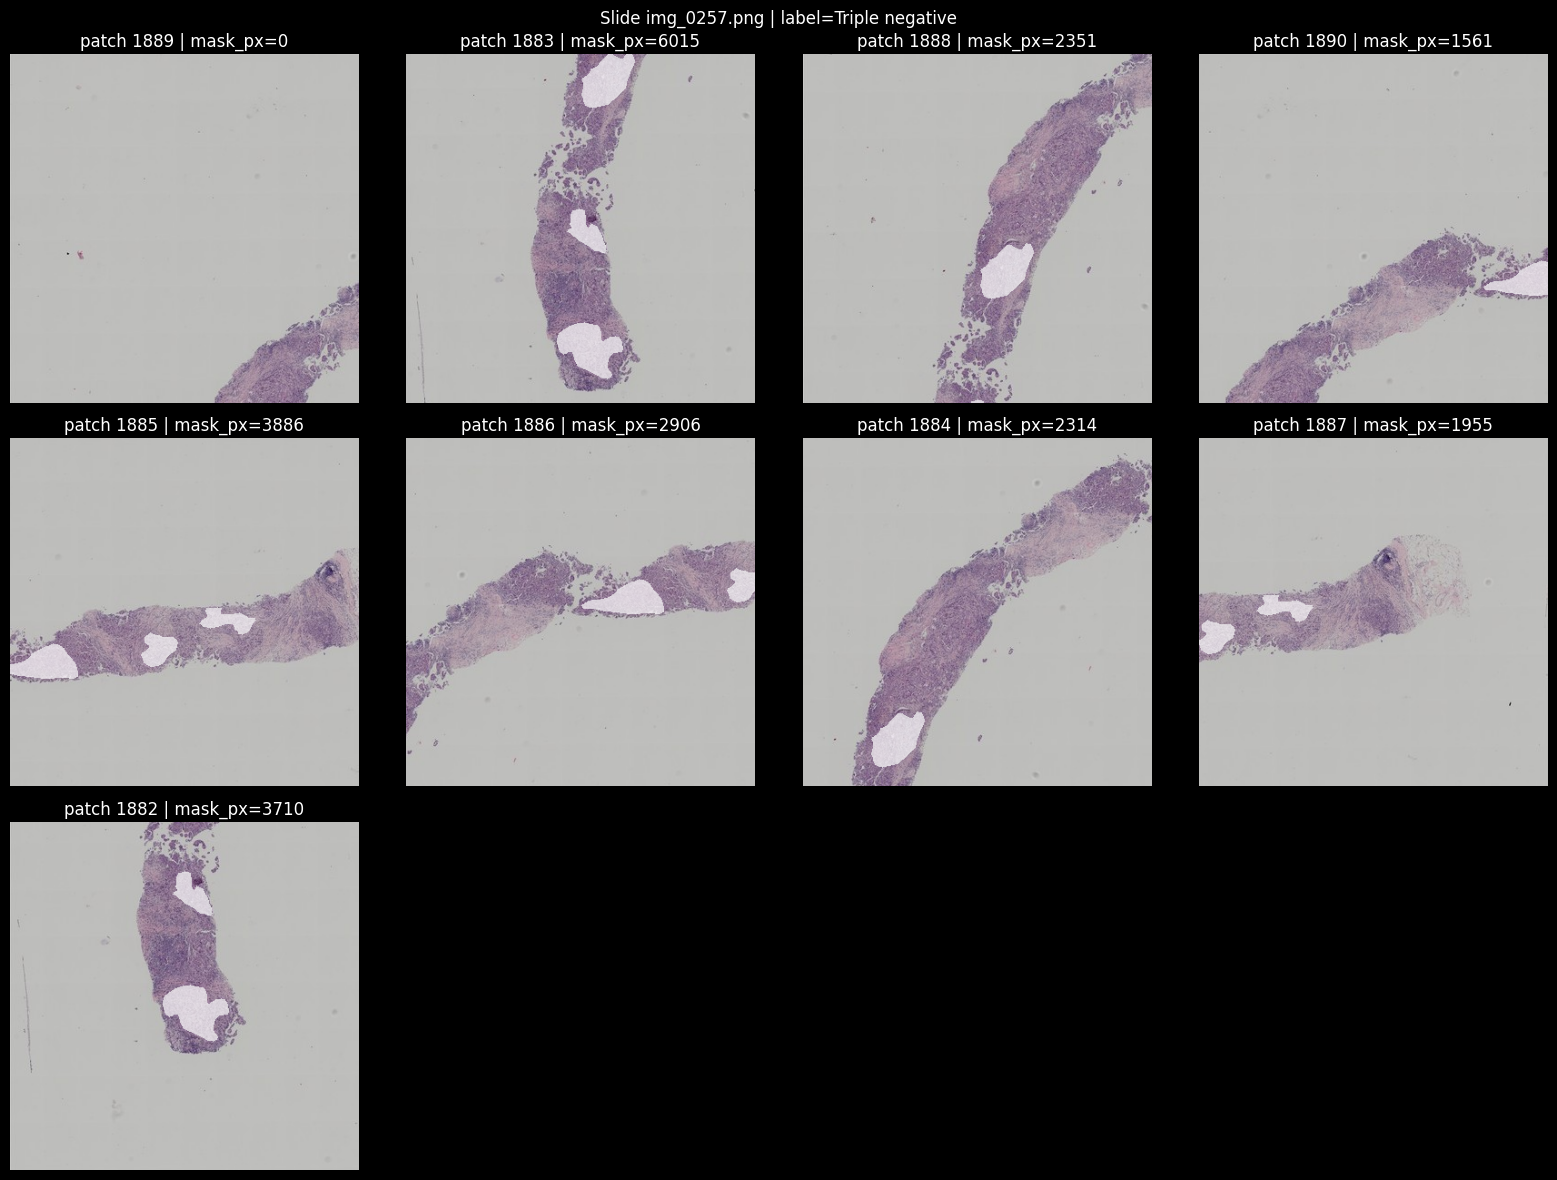

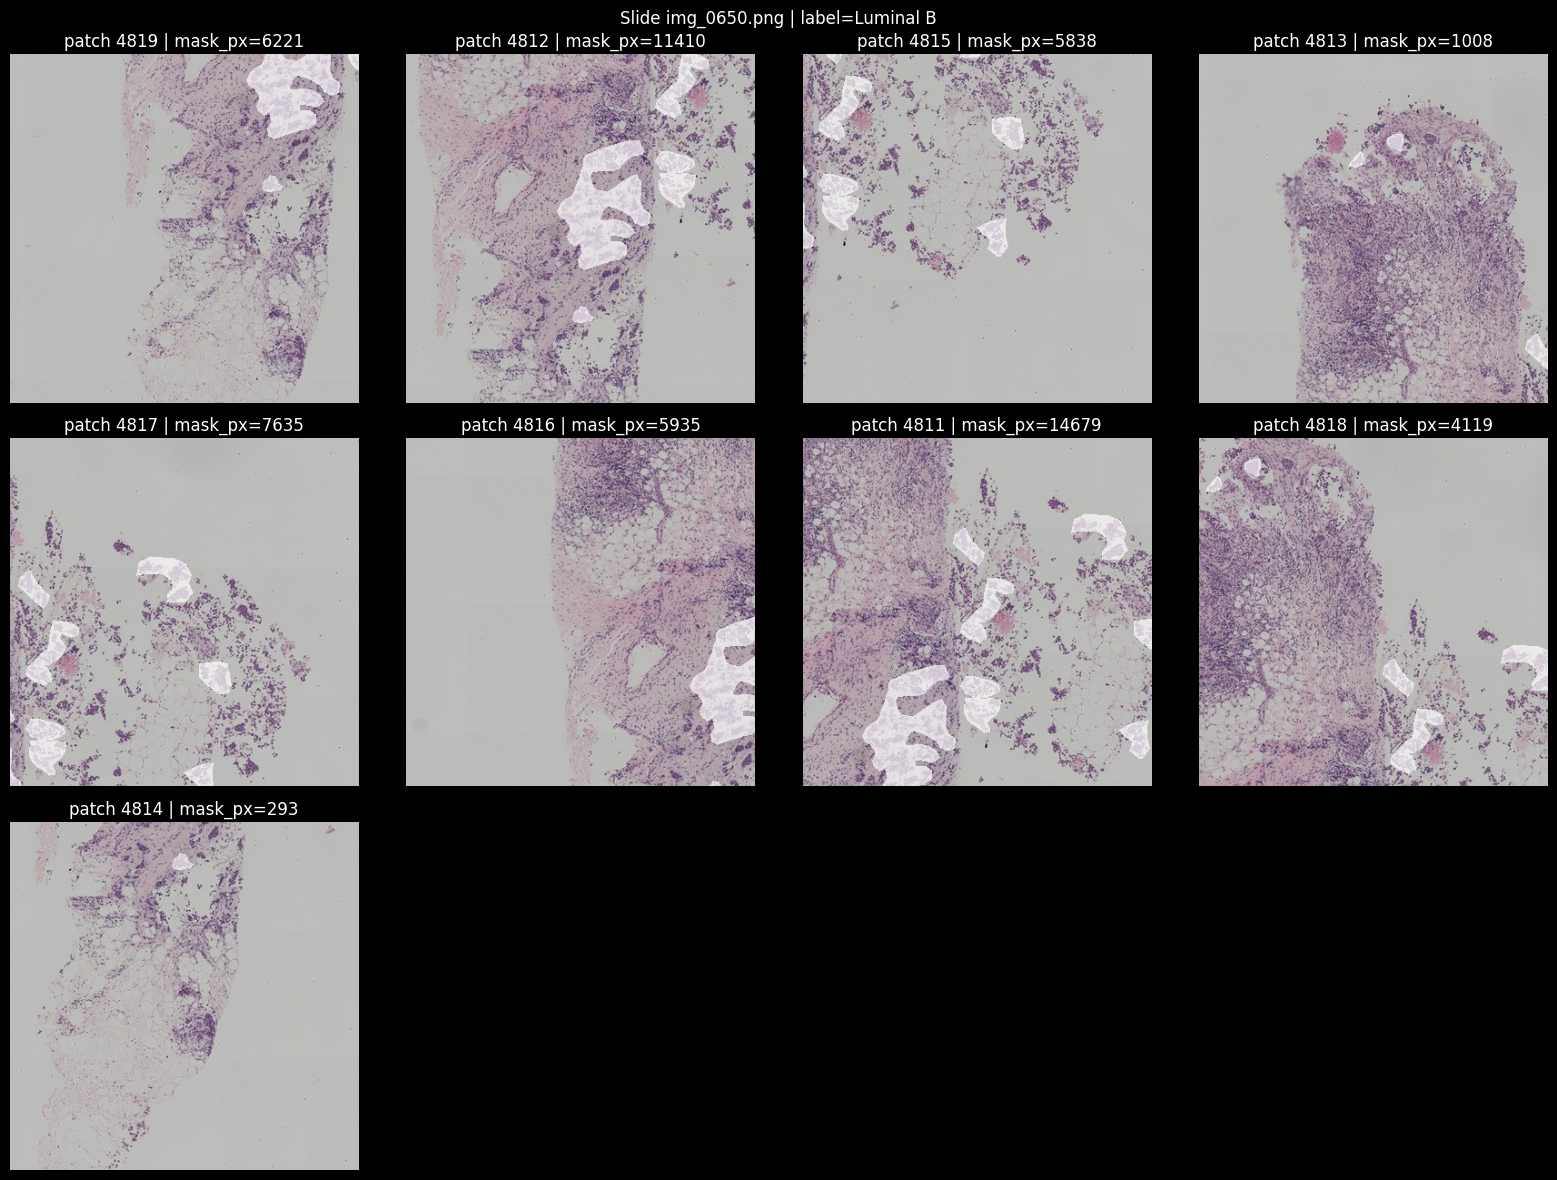

In [4]:
def show_slide_patches(slide_idx, k=12):
    start, end = slide_to_patchidx[slide_idx]
    idxs = np.arange(start, end)
    if len(idxs) == 0:
        print("No patches for slide", slide_idx)
        return
    choose = np.random.choice(idxs, size=min(k, len(idxs)), replace=False)

    n = len(choose)
    cols = 4
    rows = (n + cols - 1) // cols

    plt.figure(figsize=(4*cols, 4*rows))
    for i, pidx in enumerate(choose):
        img = X[pidx]
        msk = M[pidx, :, :, 0]

        # overlay mask (white) on image
        overlay = img.copy()
        overlay[msk > 0] = np.clip(overlay[msk > 0] * 0.3 + 255 * 0.7, 0, 255).astype(np.uint8)

        ax = plt.subplot(rows, cols, i+1)
        ax.imshow(overlay)
        ax.set_title(f"patch {pidx} | mask_px={int((msk>0).sum())}")
        ax.axis("off")

    slide_label = ID2CLASS.get(int(y[slide_idx]), f"label_{int(y[slide_idx])}")
    plt.suptitle(f"Slide {df['sample_index'].iloc[slide_idx]} | label={slide_label}")
    out_path = os.path.join("processed", "patches")
    os.makedirs(out_path, exist_ok=True)
    plt.savefig(os.path.join(out_path, f"patch_{df['sample_index'].iloc[slide_idx]}"))
    plt.tight_layout()
    plt.show()

for _ in range(2):
    s = np.random.randint(0, len(slide_to_patchidx))
    show_slide_patches(s, k=N_PATCHES)

In [5]:
def _save_slide_fig(slide_idx, k, x_path, m_path, patch_size, total_patches,
                    idx_path, y_path, df_sample_index, out_dir):
    import matplotlib
    matplotlib.use("Agg")

    slide_to_patchidx = np.load(idx_path)  # small
    y = np.load(y_path)

    X = np.memmap(x_path, dtype=np.uint8, mode="r",
                  shape=(total_patches, patch_size, patch_size, 3))
    M = np.memmap(m_path, dtype=np.uint8, mode="r",
                  shape=(total_patches, patch_size, patch_size, 1))

    start, end = slide_to_patchidx[slide_idx]
    idxs = np.arange(start, end)
    if len(idxs) == 0:
        return slide_idx, "empty"

    rng = np.random.default_rng(slide_idx)
    choose = rng.choice(idxs, size=min(k, len(idxs)), replace=False)

    n = len(choose)
    cols = 4
    rows = (n + cols - 1) // cols

    plt.figure(figsize=(4*cols, 4*rows))
    for i, pidx in enumerate(choose):
        img = X[pidx]
        msk = M[pidx, :, :, 0]
        overlay = img.copy()
        overlay[msk > 0] = np.clip(overlay[msk > 0] * 0.3 + 255 * 0.7, 0, 255).astype(np.uint8)

        ax = plt.subplot(rows, cols, i+1)
        ax.imshow(overlay)
        ax.set_title(f"patch {pidx} | mask_px={int((msk>0).sum())}")
        ax.axis("off")
    plt.suptitle(f"Slide {df['sample_index'].iloc[slide_idx]} | label={ID2CLASS[int(y[slide_idx])]}")

    slide_name = df_sample_index[slide_idx]
    os.makedirs(out_dir, exist_ok=True)
    out_path = os.path.join(out_dir, f"patch_{slide_name}")
    plt.savefig(out_path, dpi=120)
    plt.close("all")
    return slide_idx, "ok"

df_sample_index = df["sample_index"].tolist()
out_dir = os.path.join("processed", "patches")

shutil.rmtree(out_dir, ignore_errors=True)

with ProcessPoolExecutor(max_workers=os.cpu_count()//2 or 4) as ex:
    futures = [
        ex.submit(_save_slide_fig, i, N_PATCHES,
                  x_path, m_path, PATCH_SIZE, total_patches,
                  idx_path, y_path, df_sample_index, out_dir)
        for i in range(len(slide_to_patchidx))
    ]

    for fut in tqdm(as_completed(futures), total=len(futures), desc="Saving previews", unit="slide"):
        fut.result()


Saving previews: 100%|██████████| 581/581 [00:44<00:00, 13.10slide/s]


In [6]:
def patch_stats(
    X, M,
    num_random=5000,
    patch_size=384,
):
    """
    X: memmap [N, H, W, 3]
    M: memmap [N, H, W, 1]
    """
    total = X.shape[0]
    idxs = np.random.choice(total, size=min(num_random, total), replace=False)

    mask_px = []
    mask_frac = []
    gray_std = []

    for p in tqdm(idxs):
        img = X[p].astype(np.float32)
        msk = M[p, :, :, 0] > 0

        # --- mask stats ---
        mp = msk.sum()
        mask_px.append(mp)
        mask_frac.append(mp / (patch_size * patch_size))

        # --- signal quality ---
        gray = img.mean(axis=2)
        gray_std.append(gray.std())

    mask_px = np.asarray(mask_px)
    mask_frac = np.asarray(mask_frac)
    gray_std = np.asarray(gray_std)

    print("\nMask presence:")
    print(f"  % patches with any mask: {(mask_px > 0).mean():.3f}")
    print(f"  % strong mask (>5% area): {(mask_frac > 0.05).mean():.3f}")

    print("\nMask fraction distribution:")
    for q in [0, 10, 25, 50, 75, 90, 95]:
        print(f"  p{q:02d}: {np.percentile(mask_frac, q):.4f}")

    print("\nSignal quality:")
    print(f"  % low-contrast (std < 5): {(gray_std < 5).mean():.3f}")
    print(f"  gray std median: {np.median(gray_std):.2f}")

patch_stats(
    X=X,
    M=M,
    patch_size=PATCH_SIZE
)

100%|██████████| 5000/5000 [00:12<00:00, 412.53it/s]


Mask presence:
  % patches with any mask: 0.767
  % strong mask (>5% area): 0.256

Mask fraction distribution:
  p00: 0.0000
  p10: 0.0000
  p25: 0.0011
  p50: 0.0190
  p75: 0.0508
  p90: 0.1116
  p95: 0.1591

Signal quality:
  % low-contrast (std < 5): 0.000
  gray std median: 19.13


### Slide-level EDA

#### Patches per slide

In [7]:
def slide_patch_counts(slide_to_patchidx):
    counts = slide_to_patchidx[:,1] - slide_to_patchidx[:,0]
    return counts

counts = slide_patch_counts(slide_to_patchidx)

print("Patches per slide:")
print("  min:", counts.min())
print("  p10:", np.percentile(counts, 10)) # p10 indicates
print("  median:", np.median(counts))
print("  p90:", np.percentile(counts, 90))
print("  max:", counts.max())


Patches per slide:
  min: 6
  p10: 8.0
  median: 9.0
  p90: 10.0
  max: 10


#### Patches per slide by class

In [21]:
df_eda = pd.DataFrame({
    "label": y,
    "n_patches": counts
})

df_eda.groupby("label")["n_patches"].describe(percentiles=[.1, .25, .5, .9]).rename(index=ID2CLASS)

,count,mean,std,min,10%,25%,50%,90%,max
label,,,,,,,,,
Luminal A,158.0,8.822785,0.691338,8.0,8.0,8.0,9.0,10.0,10.0
Luminal B,204.0,8.823529,0.664538,7.0,8.0,8.0,9.0,10.0,10.0
HER2(+),150.0,8.806667,0.641900,8.0,8.0,8.0,9.0,10.0,10.0
Triple negative,69.0,8.797101,0.739231,6.0,8.0,8.0,9.0,10.0,10.0


### Patch-level EDA (content quality)

#### Mask pixels per patch

In [9]:
def patch_mask_stats(mask_px, num_random=5000):
    total = len(mask_px)
    idxs = np.random.choice(
        np.arange(total),
        size=min(num_random, total),
        replace=False
    )

    vals = mask_px[idxs]

    print("Mask pixels per patch:")
    print("  % with any mask:", (vals > 0).mean())
    print("  p10:", np.percentile(vals, 10))
    print("  median:", np.percentile(vals, 50))
    print("  p90:", np.percentile(vals, 90))
    print("  max:", vals.max())

patch_mask_stats(
    mask_px = np.array([
        int((M[p, :, :, 0] > 0).sum())
        for p in range(M.shape[0])
    ])
)

Mask pixels per patch:
  % with any mask: 0.766
  p10: 0.0
  median: 2821.0
  p90: 16485.0
  max: 96369


#### Empty / junk patch detection

In [10]:
def is_junk_patch(rgb):
    gray = rgb.mean(axis=2)
    return (
        gray.std() < 5 or
        np.percentile(gray, 95) > 245
    )

total = X.shape[0]  # total number of patches
num_random = 5000

idxs = np.random.choice(
    np.arange(total),
    size=min(num_random, total),
    replace=False
)

junk_rate = np.mean([is_junk_patch(X[p]) for p in idxs])
print("Junk patch rate:", junk_rate)

Junk patch rate: 0.0


### Redundancy & diversity

#### Patch similarity

100%|██████████| 5000/5000 [00:12<00:00, 397.08it/s]


Mean similarity: 0.09227202
Max similarity: 0.99914986
Patches with similarity > 0.9:
  Patch 2218 and Patch 1213: sim=0.9117
    Slide 251 (label=Luminal B), Slide 138 (label=Triple negative)
  Patch 666 and Patch 2221: sim=0.9100
    Slide 74 (label=Luminal A), Slide 252 (label=HER2(+))
  Patch 3515 and Patch 2950: sim=0.9119
    Slide 399 (label=Luminal A), Slide 335 (label=Luminal B)
  Patch 4461 and Patch 2621: sim=0.9234
    Slide 506 (label=Luminal A), Slide 297 (label=Luminal B)
  Patch 3774 and Patch 564: sim=0.9302
    Slide 428 (label=Luminal B), Slide 63 (label=Luminal B)
max_abs_diff: 188.0
equal: False
std i: 24.007818 std j: 14.519615


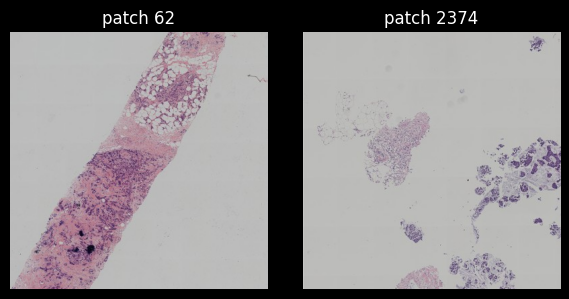

In [11]:
def patch_embedding(rgb, out=16):
    gray = rgb.mean(axis=2).astype(np.float32)       # HxW
    small = cv2.resize(gray, (out, out), interpolation=cv2.INTER_AREA)
    v = small.reshape(-1)
    v -= v.mean()
    v /= (v.std() + 1e-6)
    return v

def similarity_stats(X, idxs, out=16):
    # use tqdm for progress
    embs = np.stack([patch_embedding(X[i], out=out) for i in tqdm(idxs)], axis=0)
    sim = cosine_similarity(embs)
    np.fill_diagonal(sim, 0.0)
    print("Mean similarity:", sim.mean())
    print("Max similarity:", sim.max())
    return sim

def patch_std(p):
    p = p.astype(np.float32)
    return p.std()

def show_pair(i, j):
    fig, ax = plt.subplots(1, 2, figsize=(6,3))
    ax[0].imshow(X[i].transpose(1,2,0) if X[i].ndim==3 and X[i].shape[0] in [3,4] else X[i])
    ax[0].set_title(f"patch {i}")
    ax[0].axis("off")
    ax[1].imshow(X[j].transpose(1,2,0) if X[j].ndim==3 and X[j].shape[0] in [3,4] else X[j])
    ax[1].set_title(f"patch {j}")
    ax[1].axis("off")
    plt.tight_layout()
    plt.show()

sim = similarity_stats(X, idxs, out=16)

# print some highly similar pairs
samples = 5
THRESH = 0.9
pairs = np.argwhere(sim > THRESH)
print(f"Patches with similarity > {THRESH}:")
for i, j in pairs:
    print(f"  Patch {idxs[i]} and Patch {idxs[j]}: sim={sim[i,j]:.4f}")
    # print also label and slide info
    slide_i = np.searchsorted(slide_to_patchidx[:,1], idxs[i], side="right")
    slide_j = np.searchsorted(slide_to_patchidx[:,1], idxs[j], side="right")
    print(f"    Slide {slide_i} (label={ID2CLASS[int(y[slide_i])]}), Slide {slide_j} (label={ID2CLASS[int(y[slide_j])]})")
    samples -= 1
    if samples == 0:
        break
a = X[i]  # (C,H,W) or (H,W,C)
b = X[j]

# if float, compare robustly
max_abs = np.max(np.abs(a.astype(np.float32) - b.astype(np.float32)))
print("max_abs_diff:", max_abs)
print("equal:", np.array_equal(a, b))

print("std i:", patch_std(X[i]), "std j:", patch_std(X[j]))

show_pair(i, j)


100%|██████████| 5000/5000 [01:10<00:00, 71.17it/s]


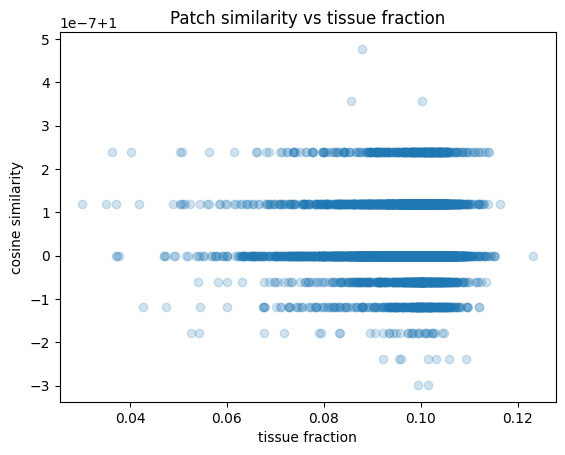

In [12]:
# Plot similarity vs tissue fraction
tissue_frac = []
similarities = []
for p in tqdm(idxs):
    rgb = X[p]
    tfrac = tissue_fraction(rgb)
    tissue_frac.append(tfrac)

    emb = patch_embedding(rgb, out=16)
    sim = cosine_similarity(emb.reshape(1,-1), emb.reshape(1,-1))[0,0]
    similarities.append(sim)

tissue_frac = np.array(tissue_frac)
similarities = np.array(similarities)
plt.style.use('default')
plt.scatter(tissue_frac, similarities, alpha=0.2)
plt.xlabel("tissue fraction")
plt.ylabel("cosine similarity")
plt.title("Patch similarity vs tissue fraction")
plt.show()

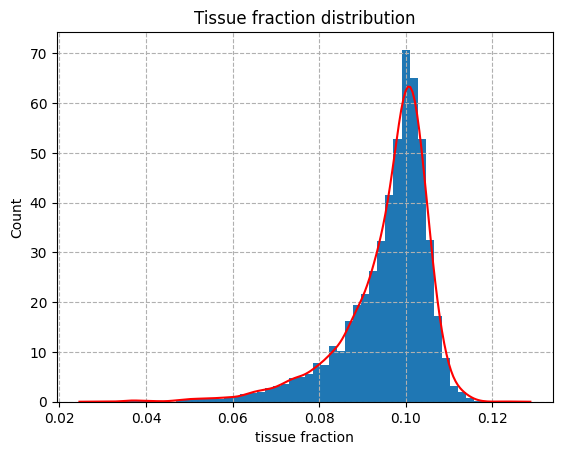

In [13]:
# Plot tissue fraction distribution
plt.hist(tissue_frac, bins=50, density=True)
plt.grid(True, linestyle='--',)
# add gaussian KDE
sns.kdeplot(tissue_frac, color='red')
plt.xlabel("tissue fraction")
plt.title("Tissue fraction distribution")
plt.ylabel("Count")
plt.show()

In [14]:
# Per-slide tissue summary
def slide_tissue_summary(slide_to_patchidx, X):
    n_slides = slide_to_patchidx.shape[0]
    summaries = []

    for s in tqdm(range(n_slides), desc="Computing per-slide tissue summaries", unit="slide"):
        start, end = slide_to_patchidx[s]
        idxs = np.arange(start, end)

        tissue_fracs = []
        for p in idxs:
            rgb = X[p]
            tfrac = tissue_fraction(rgb)
            tissue_fracs.append(tfrac)

        tissue_fracs = np.array(tissue_fracs)
        if len(tissue_fracs) == 0:
            median_tissue = 0.0
            min_tissue = 0.0
            max_tissue = 0.0
        else:
            median_tissue = float(np.median(tissue_fracs))
            min_tissue = float(np.min(tissue_fracs))
            max_tissue = float(np.max(tissue_fracs))

        summaries.append({
            "slide_idx": s,
            "n_patches": int(len(idxs)),
            "median_tissue": median_tissue,
            "min_tissue": min_tissue,
            "max_tissue": max_tissue,
        })

    return pd.DataFrame(summaries)
df_summaries = slide_tissue_summary(
    slide_to_patchidx,
    X
)
# Map slide_idx -> label using y and ID2CLASS
df_summaries["label"] = df_summaries["slide_idx"].apply(lambda s: ID2CLASS[int(y[s])])
df_summaries = df_summaries[[
    "label",
    "n_patches",
    "median_tissue",
    "min_tissue",
    "max_tissue",
]]
df_summaries.head(10)

Computing per-slide tissue summaries: 100%|██████████| 581/581 [00:55<00:00, 10.53slide/s]


,label,n_patches,median_tissue,min_tissue,max_tissue
0,Triple negative,9,0.104140,0.100186,0.107761
1,Luminal B,10,0.098219,0.086812,0.103868
2,Luminal B,9,0.103950,0.094496,0.115309
3,Luminal B,8,0.102698,0.099955,0.104289
4,Luminal A,9,0.101291,0.099067,0.104648
5,Luminal B,8,0.098423,0.091593,0.105876
6,Luminal B,9,0.099426,0.081441,0.102315
7,Luminal B,8,0.103438,0.078016,0.108548
8,Luminal A,8,0.079603,0.069912,0.094625
9,HER2(+),9,0.101895,0.098884,0.104689


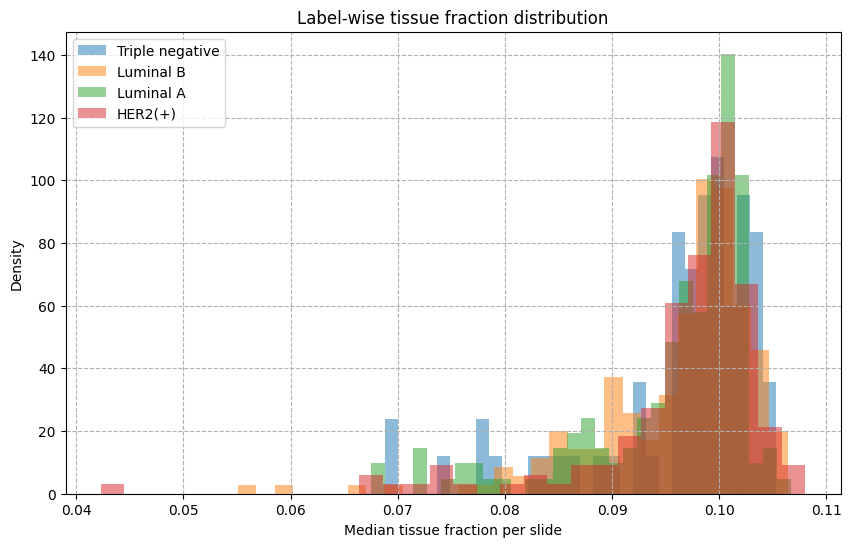

In [15]:
# Plot label-wise tissue distribution
plt.figure(figsize=(10,6))
labels = df_summaries["label"].unique()
for label in labels:
    tissue_fracs = df_summaries[df_summaries["label"] == label]["median_tissue"]
    plt.hist(tissue_fracs, bins=30, alpha=0.5, density=True, label=label)
plt.xlabel("Median tissue fraction per slide")
plt.ylabel("Density")
plt.title("Label-wise tissue fraction distribution")
plt.legend()
plt.grid(True, linestyle='--')
plt.show()

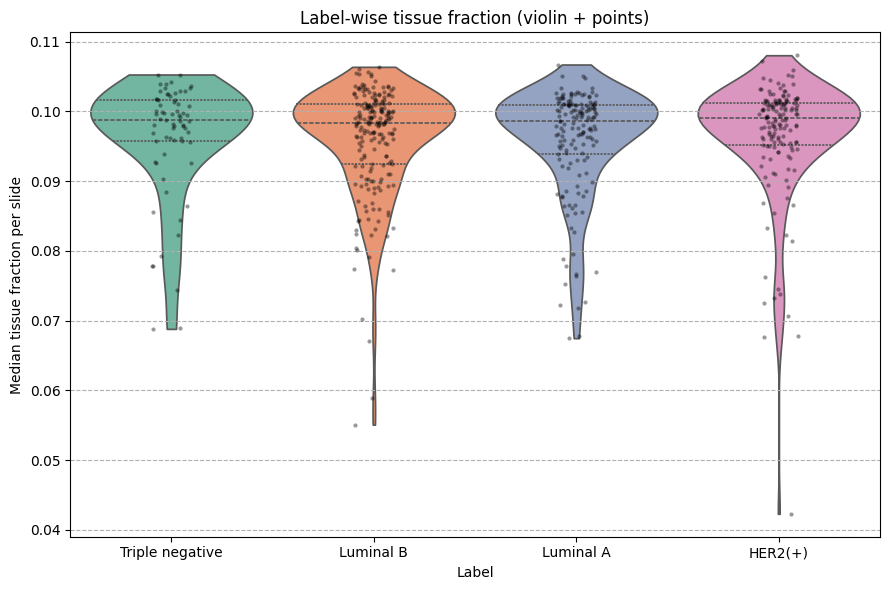

In [16]:
plt.figure(figsize=(9,6))
sns.violinplot(
    data=df_summaries,
    x="label", y="median_tissue",
    hue="label", palette="Set2", inner="quartile", cut=0,
    legend=False
)
sns.stripplot(
    data=df_summaries,
    x="label", y="median_tissue",
    color="k", alpha=0.4, size=3
)
plt.xlabel("Label")
plt.ylabel("Median tissue fraction per slide")
plt.title("Label-wise tissue fraction (violin + points)")
plt.grid(True, axis="y", linestyle='--')
plt.tight_layout()
plt.show()

In [17]:
# Save tissue summaries to CSV in log
tissue_summary_path = os.path.join(OUT_DIR, "train_slide_tissue_summary.csv")
df_summaries.to_csv(tissue_summary_path, index=False)

#### Redundancy per slide

In [18]:
def slide_redundancy(slide_idx):
    start, end = slide_to_patchidx[slide_idx]
    embs = np.array([patch_embedding(X[i]) for i in range(start, end)])
    sim = cosine_similarity(embs)
    np.fill_diagonal(sim, 0)
    return sim.max()

redundancy = [slide_redundancy(s) for s in range(len(slide_to_patchidx))]

### Label leakage & bias checks

#### Mask presence by class

In [24]:
mask_px_all = np.array([
    int((M[p, :, :, 0] > 0).sum())
    for p in range(M.shape[0])
])

df_patch = pd.DataFrame({
    "label": np.repeat(y, counts),
    "mask_px": mask_px_all
})

df_patch.groupby("label")["mask_px"].describe(percentiles=[.1, .25, .5, .9]).rename(index=ID2CLASS)

,count,mean,std,min,10%,25%,50%,90%,max
label,,,,,,,,,
Luminal A,1394.0,6061.697274,9204.869888,0.0,0.0,128.00,3017.5,16404.1,83419.0
Luminal B,1800.0,6567.676667,10253.117992,0.0,0.0,187.75,2808.5,17190.4,79658.0
HER2(+),1321.0,5599.258895,8909.704458,0.0,0.0,266.00,2728.0,14112.0,85580.0
Triple negative,607.0,6413.339374,12017.255389,0.0,0.0,0.00,2325.0,17621.4,96369.0


#### Patch count by class

In [25]:
df_eda.groupby("label")["n_patches"].describe(percentiles=[.1, .25, .5, .9]).rename(index=ID2CLASS)

,count,mean,std,min,10%,25%,50%,90%,max
label,,,,,,,,,
Luminal A,158.0,8.822785,0.691338,8.0,8.0,8.0,9.0,10.0,10.0
Luminal B,204.0,8.823529,0.664538,7.0,8.0,8.0,9.0,10.0,10.0
HER2(+),150.0,8.806667,0.641900,8.0,8.0,8.0,9.0,10.0,10.0
Triple negative,69.0,8.797101,0.739231,6.0,8.0,8.0,9.0,10.0,10.0
